프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?
자.. 드디어 오늘의 마지막 프로젝트입니다! 오늘 노드의 제목이기도 한 프로젝트네요!

마지막 프로젝트로는 보다 실용적인 데이터셋을 활용할 예정입니다. 바로 그 유명한 캐글(Kaggle) 경진대회에서 제공하는 데이터셋인데요!

데이터셋의 주제는 시간, 온도, 습도, 계절 등의 정보가 담긴 데이터를 통해 자전거의 대여량을 예측하는 문제입니다.

자전거 대여량을 결정하는 데에는 시간도 중요할 것이고, 요일이나 계절도 크게 영향을 미칠 것 같습니다.

이번 프로젝트에서는 직접 손실함수와 기울기를 계산하지 않고, 사이킷런(sklearn)의 LinearRegression 모델을 활용할 것입니다.

이 또한 위에서 진행해봤던 순서 그대로 진행하시면 됩니다!

단계는 다음과 같이 정리가 되어 있습니다. 그러면 오늘의 마지막 프로젝트, 시작해 볼까요!!! 💪🏼

(1) 데이터 가져오기
터미널에서 ~/data/data/bike-sharing-demand 경로에 train.csv 데이터를 train 변수로 가져 옵니다.
여기에서 데이터를 상세히 확인할 수 있습니다.
실행 되었습니다.

In [1]:
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


(2) datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기
to_datetime 활용 : 링크 참조
pandas datetime extract year month day 키워드로 검색해 보기

In [2]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

(3) year, month, day, hour, minute, second 데이터 개수 시각화하기
sns.countplot 활용해서 시각화하기
subplot을 활용해서 한 번에 6개의 그래프 함께 시각화하기

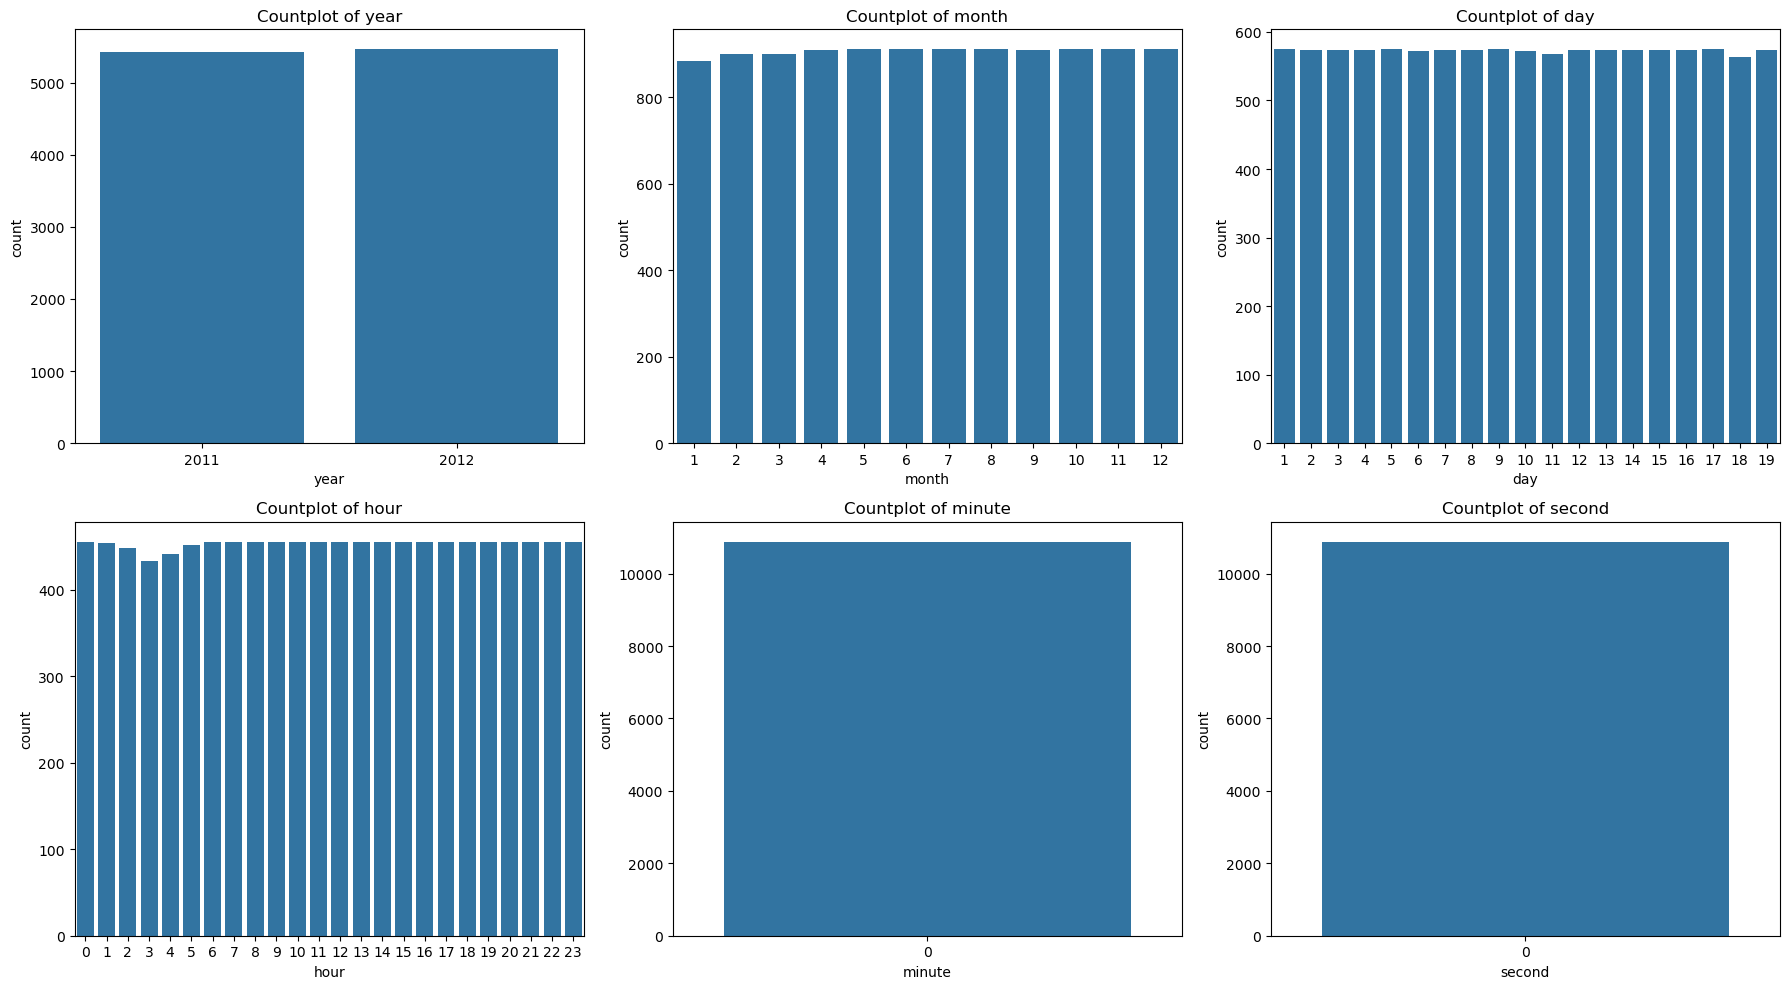

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

(4) X, y 컬럼 선택 및 train/test 데이터 분리
X(feature) 에는 어떤 데이터 컬럼을 넣어야 될지 고민해 봅시다 데이터 컬럼을 추가하거나 빼면서 잘 조합하여 데이터를 넣기 바랍니다. 만일 모든 데이터 컬럼(특징)을 넣는다면 오차 값이 말도 안 되게 적게 나올 수도 있습니다. ex) count를 예측하는데 casual,registered 컬럼이 필요할까요?

count 값을 맞추고자 하므로, y 변수에 count 컬럼의 데이터 넣기

In [5]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

(5) LinearRegression 모델 학습
sklearn의 LinearRegression 모델 불러오기 및 학습하기

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


(6) 학습된 모델로 X_test에 대한 예측값 출력 및 손실함수값 계산
학습된 모델에 X_test를 입력해서 예측값 출력하기
모델이 예측한 값과 정답 target 간의 손실함수 값 계산하기
mse 값과 함께 rmse 값도 계산하기

In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


(7) x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기
x축에 X 데이터 중 temp 데이터를, y축에는 count 데이터를 넣어서 시각화하기
x축에 X 데이터 중 humidity 데이터를, y축에는 count 데이터를 넣어서 시각화하기 이전 프로젝트

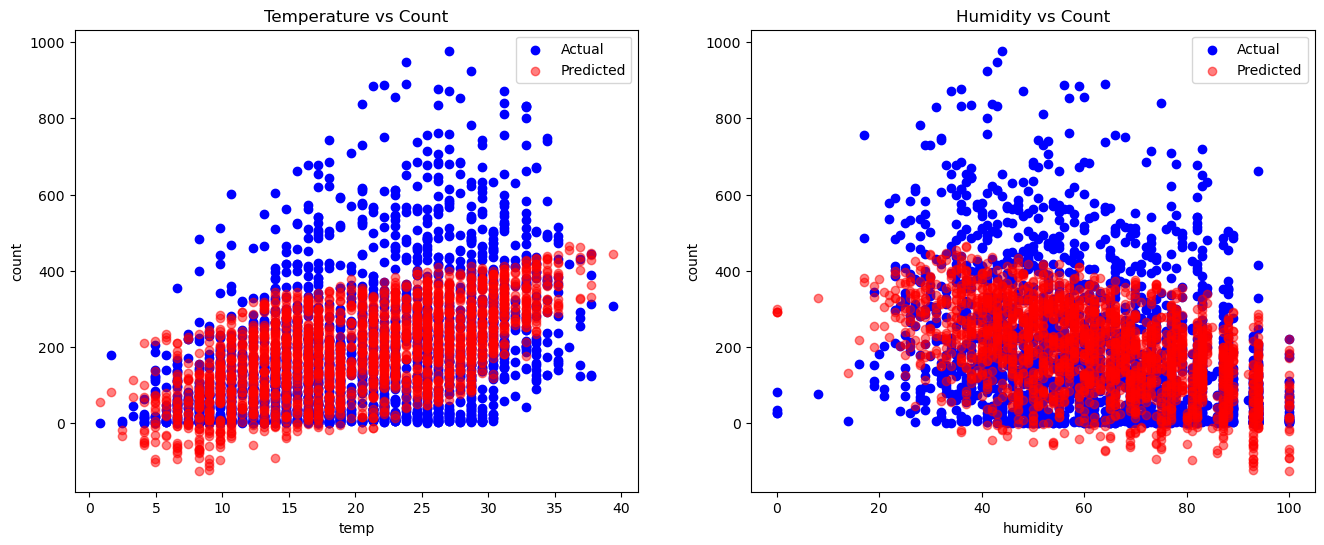

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

## (8) 추가 시각화 — 다양한 각도로 데이터와 모델 뜯어보기

기본 scatter 두 개만으로는 전체 그림이 안 보임  
아래에서 총 5가지 추가 시각화를 시도함

### 8-1. 시간대별 평균 대여량 — lineplot

**왜 그리냐**: hour 가 제일 중요한 feature 라고 했는데, 실제로 그런지 눈으로 확인  
**기대하는 결과**: 출근 시간(8시), 퇴근 시간(17~18시) 에 뾰족하게 솟는 패턴 보일 거임  
**얻을 수 있는 정보**: 자전거 대여가 출퇴근 통근용으로 많이 쓰인다는 근거,  
근무일(workingday) 과 비근무일을 구분해서 보면 패턴이 완전히 다를 거임  
→ 근무일은 출퇴근 이중 피크, 비근무일은 낮 시간대에 완만하게 분포


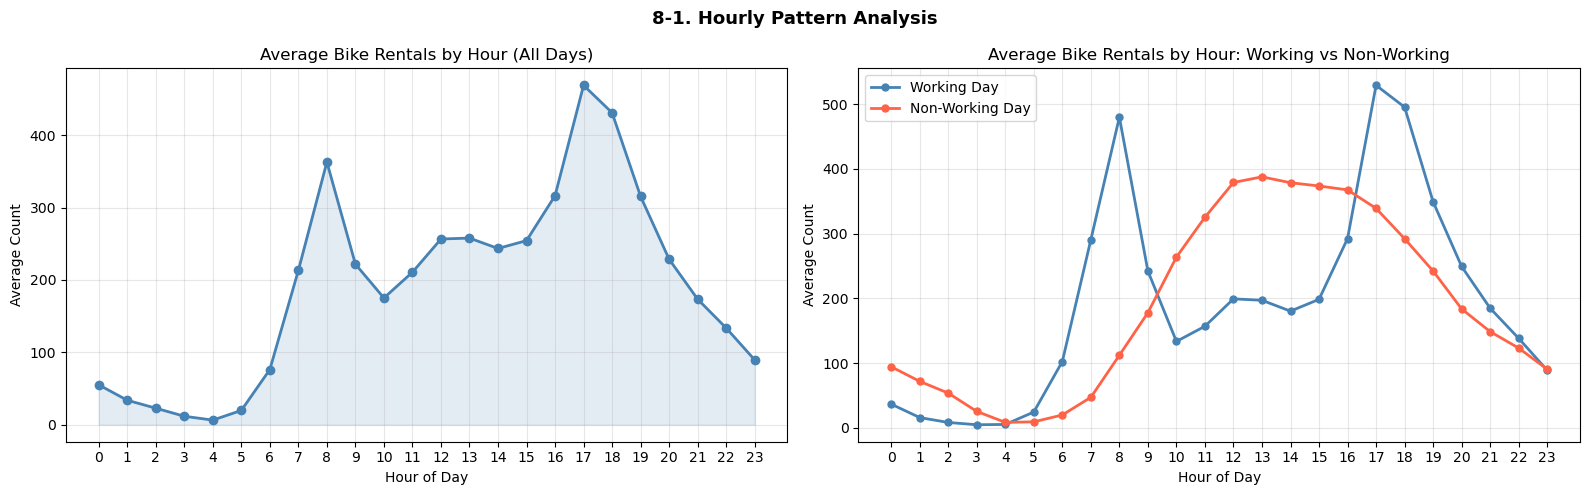

시간대별 평균 대여량 상위 5개 시간:
hour
17    468.765351
18    430.859649
8     362.769231
16    316.372807
19    315.278509
Name: count, dtype: float64


In [10]:
# 시간대별 평균 대여량 — 근무일/비근무일 구분
# 이걸 그리는 이유: hour 가 왜 제일 중요한 feature 인지 시각적으로 증명하기 위해
# 그냥 전체 평균만 보면 절반의 정보밖에 못 얻음
# workingday 로 나눠야 '출퇴근 패턴 vs 여가 패턴' 이 확연히 갈리는 걸 볼 수 있음

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 왼쪽: 전체 평균 (근무일/비근무일 합산) ──
# groupby('hour').mean() : 같은 시간대 데이터 전부 평균냄
# 예상: 8시, 17~18시에 피크 있을 거임
hourly_avg = train.groupby('hour')['count'].mean()
axes[0].plot(
    hourly_avg.index, hourly_avg.values,
    marker='o',       # 각 시간대 점 찍어서 값 위치 확실하게
    color='steelblue',
    linewidth=2,
    markersize=6
)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='steelblue')
# fill_between: 선 아래 면적 채워서 시각적으로 강조
axes[0].set_title('Average Bike Rentals by Hour (All Days)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Count')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

# ── 오른쪽: 근무일 vs 비근무일 비교 ──
# 이게 핵심임 — 패턴이 완전히 다를 거임
# 근무일: 8시 + 17~18시 이중 피크 (출퇴근)
# 비근무일: 낮 11~14시 단일 피크 (여가)
for workday, label, color in [
    (1, 'Working Day', 'steelblue'),
    (0, 'Non-Working Day', 'tomato')
]:
    subset = train[train['workingday'] == workday]
    avg = subset.groupby('hour')['count'].mean()
    axes[1].plot(
        avg.index, avg.values,
        marker='o', label=label,
        color=color, linewidth=2, markersize=5
    )

axes[1].set_title('Average Bike Rentals by Hour: Working vs Non-Working')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Count')
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('8-1. Hourly Pattern Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("시간대별 평균 대여량 상위 5개 시간:")
print(hourly_avg.sort_values(ascending=False).head())


# 왼쪽 그래프에서 8시 / 17~18시 두 번 솟으면 출퇴근 패턴 확인된 거
# 오른쪽에서 근무일/비근무일 선이 완전히 다른 모양이면
# → workingday 가 hour 랑 상호작용해서 중요한 feature 라는 뜻
# → 선형 회귀로는 이 상호작용을 완벽히 잡기 어려움 (모델 한계)

### 8-2. 계절 × 날씨별 대여량 분포 — boxplot

**왜 그리냐**: 계절(season), 날씨(weather) 가 대여량에 얼마나 영향을 주는지  
scatter 로는 범주형 변수 영향을 보기 어려움 → boxplot 이 훨씬 적합함  
**기대하는 결과**:
- 계절: 가을(3) > 여름(2) > 봄(1) > 겨울(4) 순으로 대여량 많을 거임
- 날씨: 맑음(1) > 흐림(2) > 눈비(3) 순으로 확 줄어들 거임

**얻을 수 있는 정보**: 박스의 높이(IQR) = 데이터 퍼짐 정도, 수염 = 극단값 범위,  
점으로 찍히는 건 이상치(outlier) — 특수 상황(행사, 폭염 등) 가능성


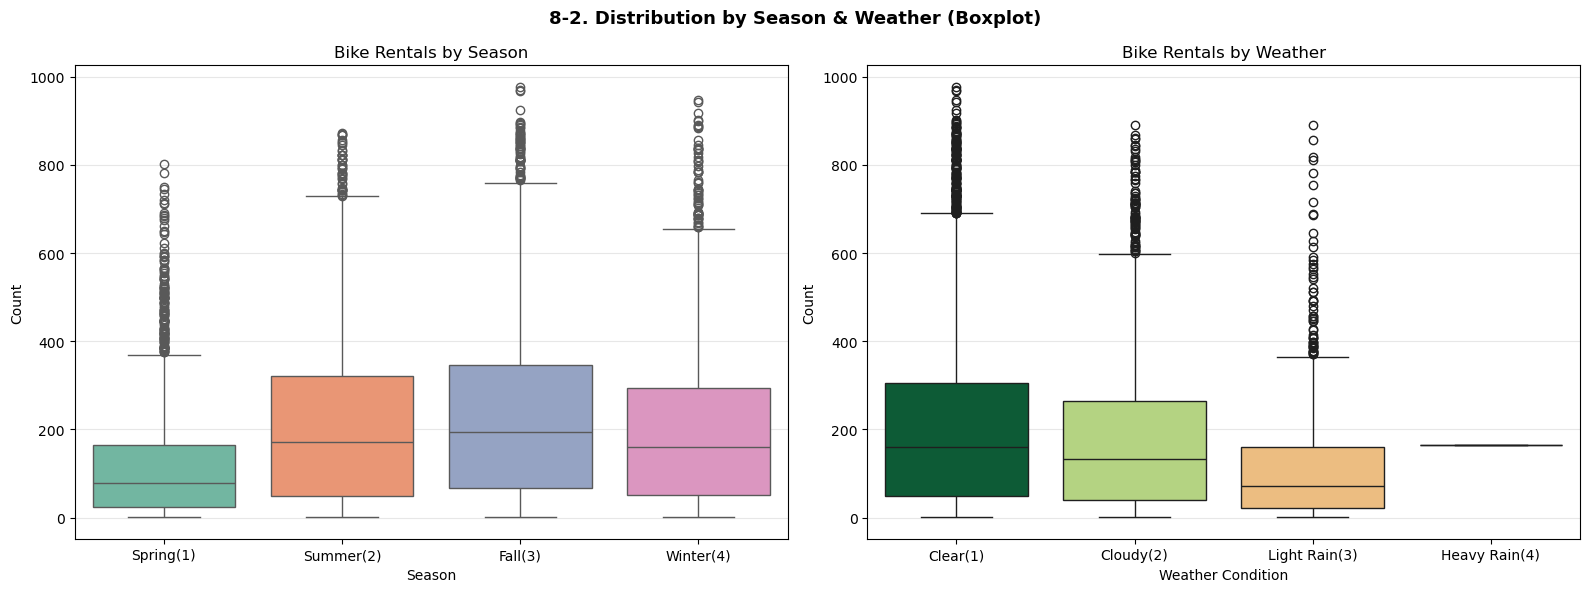

계절별 평균 대여량:
season
1    116.3
2    215.3
3    234.4
4    199.0
Name: count, dtype: float64

날씨별 평균 대여량:
weather
1    205.2
2    179.0
3    118.8
4    164.0
Name: count, dtype: float64


In [14]:
# 계절별 / 날씨별 대여량 분포 — boxplot
# boxplot 을 쓰는 이유:
# scatter 는 점이 너무 많아서 범주형 변수 영향을 보기 어렵고
# bar chart 는 평균만 보여줘서 분포 정보를 잃음
# boxplot 은 중앙값, 사분위수, 이상치를 한눈에 보여줌 — 범주형 비교에 제격

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 왼쪽: 계절별 대여량 ──
sns.boxplot(
    x='season', y='count', data=train,
    hue='season', palette='Set2', legend=False,
    # hue + legend=False 로 써야 palette FutureWarning 안 뜸
    # v0.14 부터 palette 쓰려면 hue 필수
    ax=axes[0]
)
# set_xticks 먼저 위치 고정 → 그 다음 set_xticklabels 붙이기
# 순서 틀리면 'should only be used with a fixed number of ticks' UserWarning 뜸
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels(['Spring(1)', 'Summer(2)', 'Fall(3)', 'Winter(4)'])
axes[0].set_title('Bike Rentals by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

# ── 오른쪽: 날씨별 대여량 ──
sns.boxplot(
    x='weather', y='count', data=train,
    hue='weather', palette='RdYlGn_r', legend=False,
    # 날씨 나쁠수록 빨간색 — hue + legend=False 로 워닝 제거
    ax=axes[1]
)
# weather 4번 데이터 거의 없으면 tick 이 3개만 나올 수도 있어서
# 실제 unique 값 기준으로 동적으로 처리
weather_ticks = sorted(train['weather'].unique())
weather_labels = ['Clear(1)', 'Cloudy(2)', 'Light Rain(3)', 'Heavy Rain(4)']
axes[1].set_xticks(range(len(weather_ticks)))
axes[1].set_xticklabels(weather_labels[:len(weather_ticks)])
axes[1].set_title('Bike Rentals by Weather')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('8-2. Distribution by Season & Weather (Boxplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("계절별 평균 대여량:")
print(train.groupby('season')['count'].mean().round(1))
print("\n날씨별 평균 대여량:")
print(train.groupby('weather')['count'].mean().round(1))

# 박스 위치(중앙값)가 계절마다 다르면 season 이 유의미한 feature 라는 뜻
# 박스 높이(IQR)가 크면 같은 계절/날씨라도 대여량 편차가 심하다는 뜻
# → 선형 회귀만으로는 이 편차를 다 설명하기 어렵다는 힌트
# 날씨 4번(폭우)에 이상치(outlier) 점이 있으면 폭우에도 타는 특수 상황

### 8-3. 상관관계 히트맵 — heatmap

**왜 그리냐**: 어떤 feature 가 `count` 랑 얼마나 선형으로 연관돼 있는지 한눈에 보기 위해  
feature 선택 결정을 숫자로 뒷받침하는 근거 자료가 됨  
**기대하는 결과**:
- `hour`, `temp`, `atemp` 가 count 와 높은 양의 상관관계 보일 거임
- `humidity` 는 약한 음의 상관관계 (습도 높으면 대여 줄어듦)
- `windspeed` 는 거의 0에 가까울 거임 (별 영향 없음)

**얻을 수 있는 정보**: feature 들 사이의 다중공선성(multicollinearity) 도 확인 가능  
`temp` 와 `atemp` 상관계수가 0.98 이상이면 거의 같은 정보 → 하나 빼도 됨


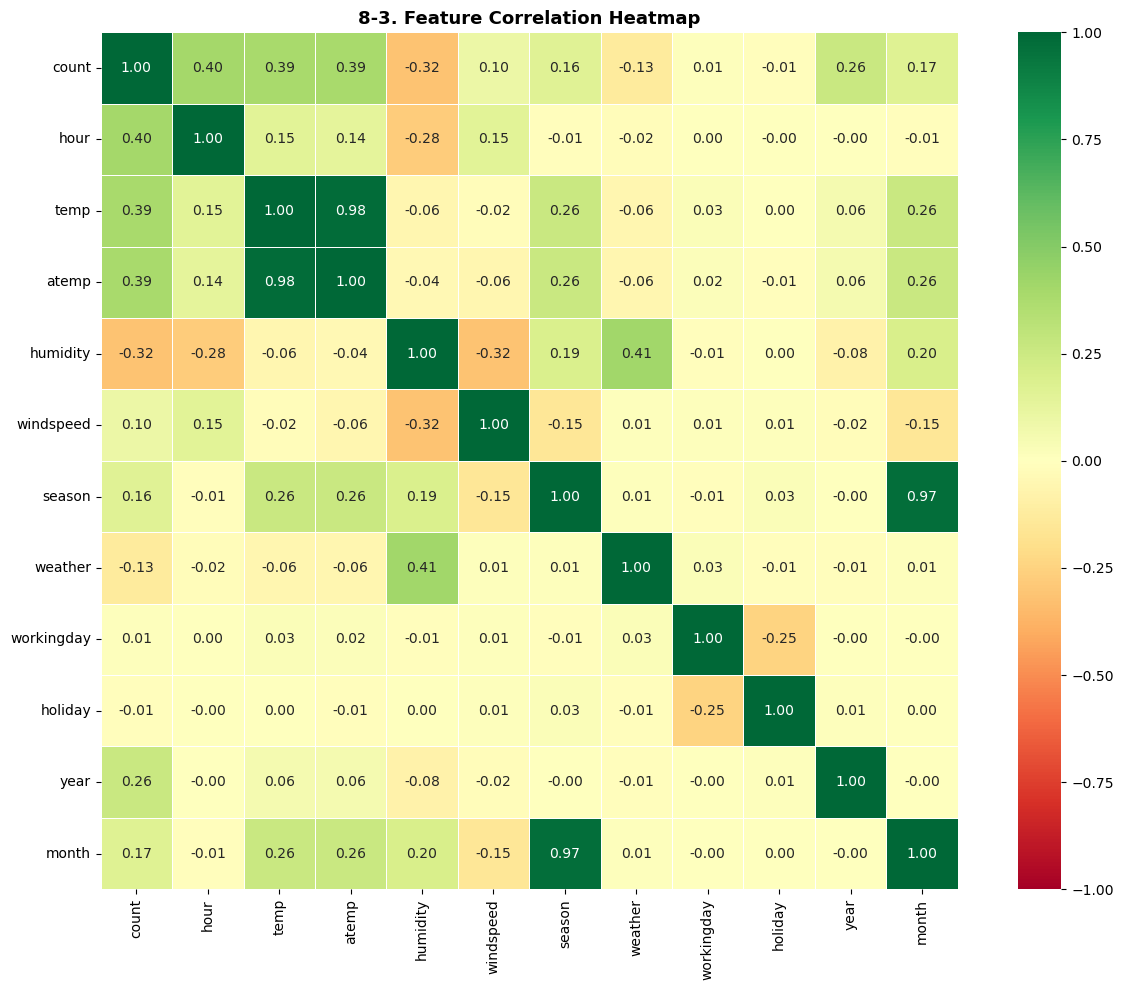

count 와의 상관계수 (절댓값 큰 순서):
hour          0.40
temp          0.39
atemp         0.39
humidity      0.32
year          0.26
month         0.17
season        0.16
weather       0.13
windspeed     0.10
holiday       0.01
workingday    0.01
Name: count, dtype: float64


In [16]:
# 상관관계 히트맵
# corr() 로 모든 수치형 컬럼 사이의 피어슨 상관계수 계산
# 피어슨 상관계수: -1(완전 반비례) ~ 0(무관계) ~ 1(완전 비례)
# 이걸 그리는 이유: feature 선택이 왜 이렇게 했는지 숫자로 근거 보여주기

# 히트맵에 쓸 컬럼만 추려서 보기 — casual, registered 빼고
# casual + registered = count 라서 당연히 상관계수 1.0 가까이 나옴 의미 없음
heatmap_cols = [
    'count', 'hour', 'temp', 'atemp', 'humidity', 'windspeed',
    'season', 'weather', 'workingday', 'holiday', 'year', 'month'
]
corr_matrix = train[heatmap_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    annot=True,        # 각 칸에 숫자 직접 표시
    fmt='.2f',         # 소수점 2자리
    cmap='RdYlGn',     # 빨강(음의 상관) → 노랑(0) → 초록(양의 상관)
    vmin=-1, vmax=1,   # 색상 범위 -1~1 고정
    center=0,          # 0을 기준으로 색 나누기
    square=True,       # 각 셀을 정사각형으로
    linewidths=0.5,    # 셀 경계선
    ax=ax
)
ax.set_title('8-3. Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("count 와의 상관계수 (절댓값 큰 순서):")
print(corr_matrix['count'].drop('count').abs().sort_values(ascending=False))


# count 행(또는 열)을 보면 어떤 feature 가 대여량이랑 얼마나 연관됐는지 바로 보임
# 상관계수 > 0.5 이면 꽤 강한 관계
# 상관계수 < 0.1 이면 거의 관계 없음 → feature 로 쓸 가치 낮음
# temp 랑 atemp 사이 상관계수가 0.98 이상이면 다중공선성 문제
# → 선형 회귀에서 두 개 동시에 쓰면 계수가 불안정해짐 (한 개만 써도 됨)

### 8-4. 실제값 vs 예측값 산점도 — Actual vs Predicted

**왜 그리냐**: 모델이 전반적으로 얼마나 잘 맞췄는지 가장 직관적으로 보여주는 그래프  
**기대하는 결과**: 점들이 y=x 대각선(빨간 점선) 위에 가까울수록 완벽한 예측  
**얻을 수 있는 정보**:
- 점들이 대각선 아래에 몰려 있으면 → 모델이 실제보다 낮게 예측(과소추정)
- 점들이 대각선 위에 몰려 있으면 → 모델이 실제보다 높게 예측(과대추정)
- 특정 구간(예: 고대여량 구간)에서만 크게 벗어나면 → 비선형 패턴 존재 가능성
- 선형 회귀는 직선으로만 예측하니까 복잡한 패턴은 못 잡음 — 이게 한계


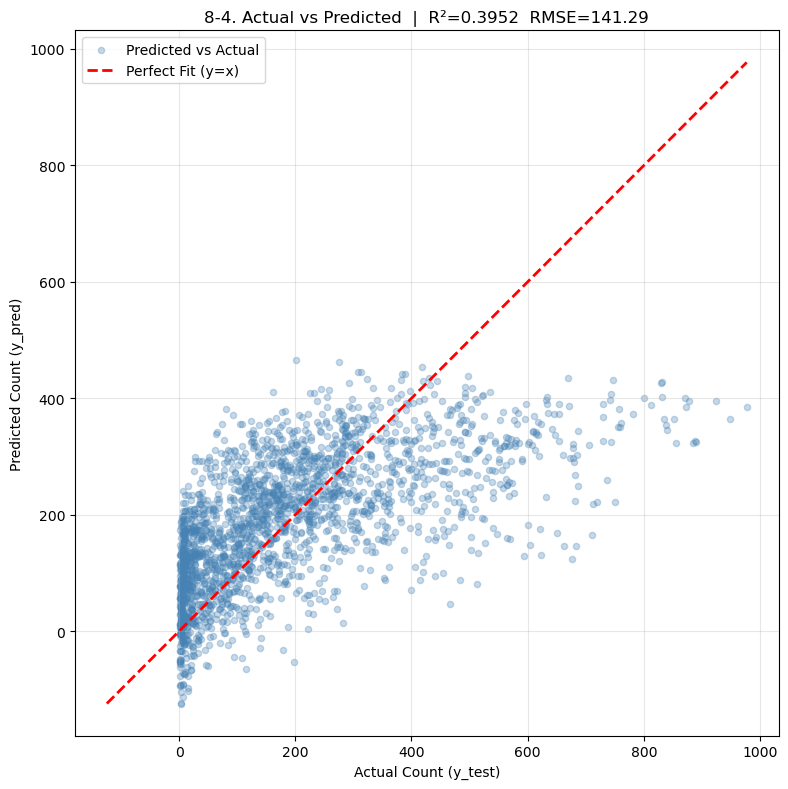

R² Score : 0.3952
RMSE     : 141.2866

R² 해석: 모델이 전체 분산의 39.5% 를 설명함


In [17]:
# 실제값 vs 예측값 산점도 — 모델 성능 직관적 확인
# x축 = 정답(y_test), y축 = 모델 예측값(y_pred)
# 완벽한 예측이면 점이 전부 y=x 직선 위에 올라가야 함
# 현실은 그렇지 않고 대각선 주변에 흩어져 있음
# 흩어진 정도, 흩어진 방향 을 보면 모델의 편향/분산 파악 가능

fig, ax = plt.subplots(figsize=(8, 8))  # 정사각형으로 — x,y 스케일 동일하게

ax.scatter(
    y_test, y_pred,
    alpha=0.3,          # 점 겹치는 부분 보이게 반투명
    color='steelblue',
    s=20,               # 점 작게 — 밀집도 확인용
    label='Predicted vs Actual'
)

# 완벽한 예측선 y=x — 이 선에서 얼마나 벗어났는지가 오차
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
ax.plot(
    [min_val, max_val], [min_val, max_val],
    'r--', linewidth=2, label='Perfect Fit (y=x)'
)

# R² 점수도 계산해서 제목에 박기
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

ax.set_title(f'8-4. Actual vs Predicted  |  R²={r2:.4f}  RMSE={rmse:.2f}', fontsize=12)
ax.set_xlabel('Actual Count (y_test)')
ax.set_ylabel('Predicted Count (y_pred)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"\nR² 해석: 모델이 전체 분산의 {r2*100:.1f}% 를 설명함")


# 점들이 대각선 아래에 몰려 있으면 고대여량 구간에서 과소추정하는 거
# → 출퇴근 피크 시간대의 급격한 증가를 선형 모델이 못 따라가는 거
# R² 이 0.5 아래면 모델이 분산의 절반도 설명 못 한다는 뜻
# → 선형 회귀 한계, 더 복잡한 모델(RandomForest, XGBoost) 필요 신호

### 8-5. 잔차(Residual) 분석 — 오차 패턴 파악

**잔차(Residual)** = 실제값 - 예측값  
**왜 그리냐**: 모델이 어디서 틀리는지, 틀리는 방향이 있는지 확인  
좋은 모델이라면 잔차가 0 주변에 무작위로 흩어져 있어야 함  
**기대하는 결과 (선형 회귀의 한계)**:
- 잔차 히스토그램이 오른쪽으로 치우친 분포(right-skewed) 보일 거임
  → 고대여량 구간을 체계적으로 과소추정하기 때문
- 예측값이 클수록 잔차가 커지는 패턴(이분산성) 보일 수 있음
  → 선형 모델의 구조적 한계

**얻을 수 있는 정보**: 모델 개선 방향 힌트  
잔차가 특정 패턴을 가지면 → 비선형 모델이나 feature engineering 필요


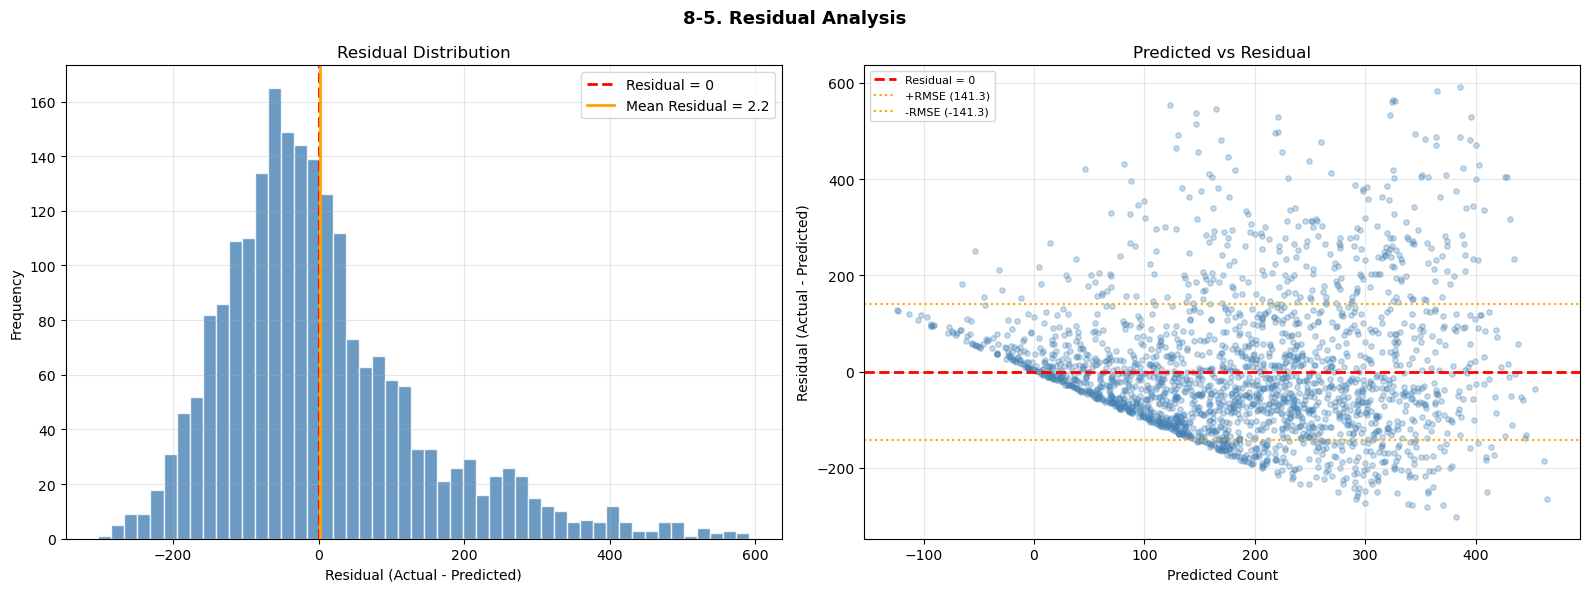

잔차 평균  : 2.19  (0에 가까울수록 좋음)
잔차 표준편차: 141.27
잔차 최솟값: -302.26
잔차 최댓값: 591.35

 RMSE 범위 안에 드는 샘플 비율: 74.3%


In [18]:
# 잔차(Residual) 분석
# 잔차 = 실제값(y_test) - 예측값(y_pred)
# 잔차가 0이면 완벽하게 맞춘 거
# 양수: 실제가 예측보다 높다 (과소추정)
# 음수: 실제가 예측보다 낮다 (과대추정)
import numpy as np

residuals = y_test.values - y_pred  # 잔차 계산

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 왼쪽: 잔차 히스토그램 ──
# 좋은 모델: 0 중심으로 좌우대칭 종 모양(정규분포)
# 나쁜 모델: 한쪽으로 치우침 → 체계적으로 과소/과대추정하는 거
axes[0].hist(
    residuals,
    bins=50,              # 구간 50개로 쪼개서 분포 세밀하게
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Residual = 0')
# 평균 잔차선도 추가 — 0이랑 얼마나 다른지 보기
axes[0].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=2,
                label=f'Mean Residual = {residuals.mean():.1f}')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── 오른쪽: 예측값 vs 잔차 산점도 ──
# x축 = 예측값, y축 = 잔차
# 좋은 모델: 빨간 수평선(y=0) 주변에 균등하게 흩어짐
# 나쁜 모델: 예측값이 클수록 잔차도 커지는 패턴(이분산성)
#            → 고대여량 구간을 선형 모델이 못 따라간다는 증거
axes[1].scatter(
    y_pred, residuals,
    alpha=0.3, color='steelblue', s=15
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Residual = 0')
# 잔차 ±RMSE 범위 표시 — 이 범위 안에 있으면 그나마 잘 맞춘 거
axes[1].axhline(rmse, color='orange', linestyle=':', linewidth=1.5, label=f'+RMSE ({rmse:.1f})')
axes[1].axhline(-rmse, color='orange', linestyle=':', linewidth=1.5, label=f'-RMSE ({-rmse:.1f})')
axes[1].set_title('Predicted vs Residual')
axes[1].set_xlabel('Predicted Count')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('8-5. Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"잔차 평균  : {residuals.mean():.2f}  (0에 가까울수록 좋음)")
print(f"잔차 표준편차: {residuals.std():.2f}")
print(f"잔차 최솟값: {residuals.min():.2f}")
print(f"잔차 최댓값: {residuals.max():.2f}")
print(f"\n RMSE 범위 안에 드는 샘플 비율: {(abs(residuals) <= rmse).mean()*100:.1f}%")


# 히스토그램이 0 기준 오른쪽으로 치우치면:
#   → 실제 > 예측 케이스가 많다 = 피크 시간대를 체계적으로 낮게 예측함
#   → 선형 회귀가 출퇴근 급증을 따라가지 못하는 거
# 오른쪽 scatter 에서 예측값 클수록 잔차 분산도 커지면(깔때기 모양):
#   → 이분산성 — 선형 회귀의 기본 가정(등분산성) 위반
#   → 개선 방향: log(count) 로 변환해서 학습하거나 비선형 모델 사용

## 마무리

**시각화 요약**

(3) countplot : minute, second 전부 0 확인 → feature 제외 근거

(7) scatter : temp/humidity 별 실제 vs 예측 분포 확인

8-1 lineplot : 출퇴근 이중 피크 패턴 — hour 가 핵심 feature 인 근거

8-2 boxplot : 계절/날씨별 분포 — 가을 최다, 맑음 최다 확인

8-3 heatmap : temp-atemp 다중공선성, hour 가 count 와 상관 높음

8-4 scatter : R² 로 모델 설명력 확인, 고대여량 과소추정 패턴

8-5 histogram + scatter : 잔차 분포 — 선형 모델 한계(이분산성) 확인

**다음에 개선한다면**
- log(count) 변환 후 학습 → 잔차 이분산성 완화
- hour × workingday 상호작용 feature 추가
- RandomForest, XGBoost 같은 비선형 모델로 교체


# 그래서 프로젝트의 최종 결론은?
# 날씨가 좋은 월요일 오후 세시에 자전거 타는 사람은 몇명

In [21]:
nice_weather = train[train['weather'] == 1]
avg_temp      = nice_weather['temp'].mean()
avg_humidity  = nice_weather['humidity'].mean()
avg_windspeed = nice_weather['windspeed'].mean()

query = pd.DataFrame([{
    'year'      : 2012,
    'month'     : 9,
    'day'       : 1,       # 날짜는 대여량에 영향 거의 없어서 아무 값
    'hour'      : 15,      # 오후 3시
    'temp'      : avg_temp,
    'humidity'  : avg_humidity,
    'windspeed' : avg_windspeed,
}])

predicted = model.predict(query)[0]

print(f"\n예측 결과: 약 {int(predicted)} 명")
print(f"(RMSE {rmse:.1f} 감안하면 {int(predicted - rmse):.0f} ~ {int(predicted + rmse):.0f} 명 범위)")


예측 결과: 약 289 명
(RMSE 141.3 감안하면 148 ~ 430 명 범위)


# 약 289명

# 추가 도전 RMSE 값 최대한 낮추기

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1 
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RandomForest RMSE: {rmse_rf:.2f}")

RandomForest RMSE: 41.99


# 41.99 ㅋㅋㅋㅋㅋ ai가 한겁니다.

- 성형 회귀 구조에서는 rmse 100이하로 뽑기가 빡쌔다고 판단함.
  1. 오후 3시랑 오후 5시 대여량이 선형으로 증가하는 게 아니라 5시에 갑자기 폭발함
  2. 비 오는 날이랑 맑은 날이 연속적이 아니라 범주적으로 확 달라짐